In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
sys.path.append(os.path.abspath('..'))
from lib import resize_img


In [2]:
def notebook_imshow(img):
    plt.figure(figsize=(16, 8))
    # RGB img
    if len(img.shape) == 3:
        plt.imshow(img)
    # gray img
    else: 
        plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.show()


In [3]:
# init (row, col) empty cells
class Cell:
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.hlength = 1
        self.vlength = 1

    def set_hlength(self, length):
        self.hlength = length

    def set_vlength(self, length):
        self.vlength = length

    def __str__(self):
        return f"x={self.x}, y={self.y}, hlength={self.hlength}, vlength={self.vlength}"

img shape: (1440, 3440)


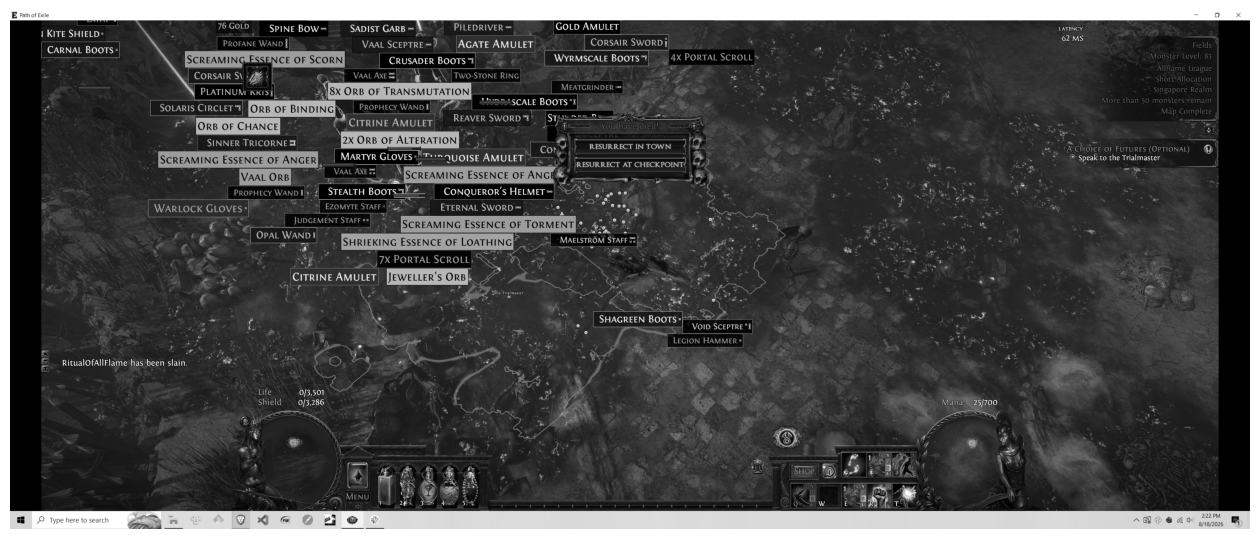

In [20]:
image = cv2.imread("../imgs/Capture4.PNG")
# resized_color_img, _ = resize_img(image[0:194, 0:319, :])
gray_img = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) #shape:[R, C] = (row, col)

cells = []
for i in range(0, gray_img.shape[0]):
    hcells = []
    for j in range(0, gray_img.shape[1]):
        hcells.append(Cell(j, i))
    cells.append(hcells)

print(f'img shape: {gray_img.shape}')
notebook_imshow(gray_img)

In [21]:
gray_img[86:90, 86:90]

array([[  0,  23,  23,  23],
       [  0,   0,   0,   0],
       [  0, 180, 180, 180],
       [  0, 180,  23,  23]], dtype=uint8)

In [22]:
# find all subarrays with identical elements in the horizontal direction
# first, for every row, compare ith & ith+1 pixels
horizontal_diff = gray_img[:, :-1] != gray_img[:, 1:] # shape: (row, col - 1)
print(horizontal_diff[86:90, 86:90])
# append an offset column (all valued 1) at the start & end of the diff array
offset = np.ones(horizontal_diff.shape[0])
horizontal_diff = np.column_stack((offset, horizontal_diff, offset)) # shape: (row, col + 1)
# offset = np.ones(horizontal_diff.shape[1])
# horizontal_diff = np.vstack((offset, horizontal_diff, offset))
horizontal_diff[86:90, 87:91]

[[ True False False False]
 [False False False False]
 [ True False False False]
 [ True  True False False]]


array([[1., 0., 0., 0.],
       [0., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 1., 0., 0.]])

In [23]:
# find non zero indices in each row
# this could also viewed as finding the start index of all subarrays that have the same elements
# thanks to the offset column ealier, we won't miss the first subarray
hline_start_indices = [np.flatnonzero(row) for row in horizontal_diff] # list of arrays with varies length (`row` arrays, max `col` + 1 elements)
hline_start_indices

[array([   0, 3440]),
 array([   0, 3440]),
 array([   0, 3440]),
 array([   0, 3440]),
 array([   0, 3440]),
 array([   0,    4,    5,    6,    7,    8,    9,   10,   11,   12,   13,
          14,   15,   16,   17,   18,   19,   20, 3440]),
 array([   0,    4,    5,    6,    7,    8,    9,   10,   11,   12,   13,
          14,   15,   16,   17,   18,   19,   20, 3440]),
 array([   0,    4,    5,    6,    7,    8,    9,   10,   11,   12,   13,
          14,   15,   16,   18,   19,   20, 3440]),
 array([   0,    5,    6,    7,    8,    9,   10,   11,   12,   13,   14,
          16,   17,   18,   19,   20, 3345, 3355, 3402, 3403, 3404, 3412,
        3413, 3414, 3440]),
 array([   0,    5,    6,    7,    8,    9,   10,   11,   12,   13,   14,
          15,   16,   17,   18,   19,   20,   28,   29,   32,   33,   34,
          47,   48,   49,   50,   70,   71,   72,   73,   74,   78,   79,
          83,   84,   85,   93,   94,   95,   96,   97,   98,   99, 3345,
        3346, 3354, 3355, 34

In [24]:
# find length of the subarrays by subtracting the start index of the next array to the it's previous array
hline_length = [row[1:] - row[:-1] for row in hline_start_indices]
hline_length[88]
for i, arr in enumerate(hline_start_indices):
    for j in range(0, len(arr) - 1):
        cells[i][arr[j]].set_hlength(hline_length[i][j])
print(cells[88][87])

x=87, y=88, hlength=217, vlength=1


In [25]:
# next, find all subarrays with identical elements in the vertical direction
vertical_diff = gray_img[1:, :] != gray_img[:-1, :]
gray_img[86:106, 86:90]

array([[  0,  23,  23,  23],
       [  0,   0,   0,   0],
       [  0, 180, 180, 180],
       [  0, 180,  23,  23],
       [  0, 180,  23,  23],
       [  0, 180,  23,  23],
       [  0, 180,  23,  23],
       [  0, 180,  23,  23],
       [  0, 180,  23,  23],
       [  0, 180,  23,  23],
       [  0, 180,  23,  23],
       [  0, 180,  23,  23],
       [  0, 180,  23,  23],
       [  0, 180,  23,  23],
       [  0, 180,  23,  23],
       [  0, 180,  23,  23],
       [  0, 180,  23,  23],
       [  0, 180,  23,  23],
       [  0, 180,  23,  23],
       [  0, 180,  23,  23]], dtype=uint8)

In [26]:
offset = np.ones(vertical_diff.shape[1])
vertical_diff = np.vstack((offset, vertical_diff, offset))
vertical_diff.shape

(1441, 3440)

In [27]:
vertical_diff[:, 87]

array([1., 0., 0., ..., 0., 1., 1.], shape=(1441,))

In [28]:
vline_start_indices = [np.flatnonzero(c) for c in vertical_diff.T]
len(vline_start_indices)

3440

In [29]:
vline_length = [c[1:] - c[:-1] for c in vline_start_indices]
vline_length
for i, arr in enumerate(vline_start_indices):
    for j in range(0, len(arr) - 1):
        cells[arr[j]][i].set_vlength(vline_length[i][j])
print(cells[88][87])

x=87, y=88, hlength=217, vlength=45


In [36]:
MINIMUM_CURRENCY_BOX_WIDTH = 120
MAXIMUM_CURRENCY_BOX_WIDTH = 500
MINIMUM_CURRENCY_BOX_HEIGHT = 35
MAXIMUM_CURRENCY_BOX_HEIGHT = 60

x=1509, y=29, hlength=185, vlength=38
x=692, y=30, hlength=191, vlength=44
x=917, y=30, hlength=208, vlength=44
x=1594, y=68, hlength=234, vlength=45
x=1238, y=70, hlength=219, vlength=49
x=1239, y=71, hlength=217, vlength=47
x=87, y=88, hlength=217, vlength=45
x=1828, y=109, hlength=238, vlength=44
x=1829, y=110, hlength=236, vlength=42
x=1483, y=112, hlength=289, vlength=44
x=484, y=113, hlength=446, vlength=48
x=485, y=114, hlength=444, vlength=46
x=1025, y=119, hlength=266, vlength=44
x=1026, y=120, hlength=264, vlength=42
x=494, y=161, hlength=150, vlength=44
x=881, y=201, hlength=400, vlength=50
x=882, y=202, hlength=398, vlength=47
x=512, y=206, hlength=133, vlength=43
x=1281, y=233, hlength=293, vlength=45
x=1282, y=234, hlength=291, vlength=43
x=389, y=250, hlength=256, vlength=44
x=660, y=250, hlength=244, vlength=49
x=661, y=251, hlength=242, vlength=46
x=1202, y=278, hlength=243, vlength=44
x=1486, y=278, hlength=189, vlength=44
x=1487, y=279, hlength=187, vlength=42
x=934,

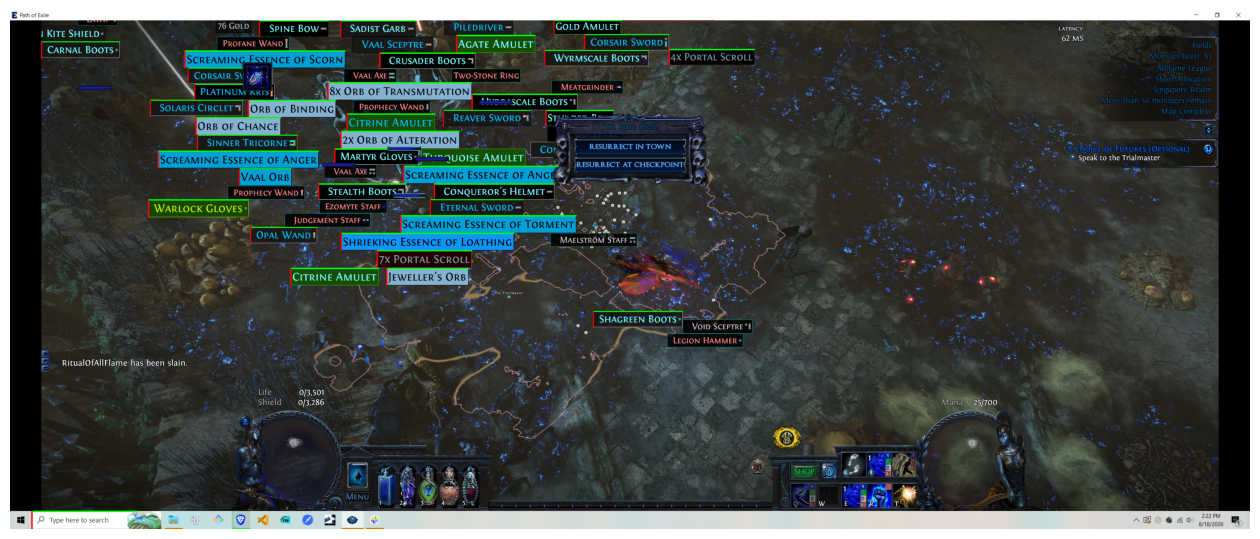

In [37]:
# iterates over all elements in `valid hlines`, check whether it's in the same indices with a vertical one
# if it does, use ocr software to extract text in the box
img = image.copy()
for i in range(0, img.shape[0]):
    for j in range(0, img.shape[1]):
        cell = cells[i][j]
        if MAXIMUM_CURRENCY_BOX_WIDTH > cell.hlength > MINIMUM_CURRENCY_BOX_WIDTH and MAXIMUM_CURRENCY_BOX_HEIGHT > cell.vlength > MINIMUM_CURRENCY_BOX_HEIGHT:
            print(cell)
            cv2.line(img, (j, i), (j + cell.hlength, i), (0, 255, 0), 2)
            cv2.line(img, (j, i), (j, i + cell.vlength), (255, 0, 0), 2)

success = cv2.imwrite('output_image.png', img)
notebook_imshow(img)